In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv('../data/cleaned_diabetes.csv')

print(f"Cleaned dataset shape: {df.shape}")
print(f"Unique patients: {df['patient_nbr'].nunique():,}")
print(f"Encounters per patient (top 5):")
print(df['patient_nbr'].value_counts().head())

Cleaned dataset shape: (97822, 50)
Unique patients: 68,885
Encounters per patient (top 5):
patient_nbr
88785891    39
1660293     23
23199021    23
88227540    23
23643405    22
Name: count, dtype: int64


In [2]:
# 80/20 split, grouped by patient_nbr
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

train_idx, test_idx = next(splitter.split(df, groups=df['patient_nbr']))
df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

print(f"Train: {len(df_train):,} encounters ({df_train['patient_nbr'].nunique():,} patients)")
print(f"Test:  {len(df_test):,} encounters ({df_test['patient_nbr'].nunique():,} patients)")

# Verify no patient leakage across split
train_patients = set(df_train['patient_nbr'])
test_patients = set(df_test['patient_nbr'])
overlap = train_patients & test_patients
print(f"\nPatient overlap between train and test: {len(overlap)}")
print(f"If 0, the split is leakage-safe.")

# Verify stratification didn't break (post-hoc check)
print(f"\nTrain target rate: {df_train['target'].mean()*100:.2f}%")
print(f"Test target rate:  {df_test['target'].mean()*100:.2f}%")
print(f"Should both be near 11.46%")

Train: 78,283 encounters (55,108 patients)
Test:  19,539 encounters (13,777 patients)

Patient overlap between train and test: 0
If 0, the split is leakage-safe.

Train target rate: 11.33%
Test target rate:  11.96%
Should both be near 11.46%


In [3]:
df_train.to_csv('../data/df_train.csv', index=False)
df_test.to_csv('../data/df_test.csv', index=False)

print(f"Saved df_train.csv ({len(df_train):,} rows)")
print(f"Saved df_test.csv  ({len(df_test):,} rows)")

Saved df_train.csv (78,283 rows)
Saved df_test.csv  (19,539 rows)


In [4]:
df_train_check = pd.read_csv('../data/df_train.csv')
df_test_check = pd.read_csv('../data/df_test.csv')
assert df_train_check.shape == df_train.shape
assert df_test_check.shape == df_test.shape

In [5]:
feature_cols = [ c for c in df_train.columns if c not in ['encounter_id', 'patient_nbr', 'target']]

X_train = df_train[feature_cols].copy()
y_train = df_train['target'].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test['target'].copy()

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (78283, 47), y_train: (78283,)
X_test:  (19539, 47),  y_test:  (19539,)


In [6]:
# get all string-type (categorical) columns
categorical_cols = X_train.select_dtypes(include='object').columns

# loop through and inspect each
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(X_train[col].value_counts(dropna=False).head(10))


/tmp/ipykernel_33123/633098692.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include='object').columns



=== race ===
race
Caucasian          58490
AfricanAmerican    14831
unknown             1675
Hispanic            1576
Other               1198
Asian                513
Name: count, dtype: int64

=== gender ===
gender
Female    42187
Male      36096
Name: count, dtype: int64

=== age ===
age
[70-80)     20178
[60-70)     17541
[50-60)     13435
[80-90)     13085
[40-50)      7556
[30-40)      2811
[90-100)     2037
[20-30)      1208
[10-20)       374
[0-10)         58
Name: count, dtype: int64

=== payer_code ===
payer_code
unknown    30971
MC         24770
HM          4914
SP          3810
BC          3627
MD          2750
CP          1926
UN          1884
CM          1522
OG           811
Name: count, dtype: int64

=== medical_specialty ===
medical_specialty
unknown                       38485
InternalMedicine              11286
Emergency/Trauma               5903
Family/GeneralPractice         5652
Cardiology                     4157
Surgery-General                2379
Nephrology   

In [7]:
medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
                   'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 
                   'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
                   'miglitol', 'troglitazone', 'tolazamide', 'examide', 
                   'citoglipton', 'insulin', 'glyburide-metformin', 
                   'glipizide-metformin', 'glimepiride-pioglitazone',
                   'metformin-rosiglitazone', 'metformin-pioglitazone']

X_train[medication_cols].nunique().sort_values()

examide                     1
citoglipton                 1
tolbutamide                 2
acetohexamide               2
glimepiride-pioglitazone    2
metformin-rosiglitazone     2
glipizide-metformin         2
troglitazone                2
metformin-pioglitazone      2
tolazamide                  3
glimepiride                 4
glipizide                   4
glyburide                   4
metformin                   4
nateglinide                 4
repaglinide                 4
miglitol                    4
pioglitazone                4
rosiglitazone               4
acarbose                    4
chlorpropamide              4
insulin                     4
glyburide-metformin         4
dtype: int64

In [8]:
near_constant = ['tolbutamide', 'acetohexamide', 'troglitazone',
                 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                 'glipizide-metformin', 'metformin-pioglitazone', 'tolazamide']

for col in near_constant:
    print(f"\n{col}:")
    print(X_train[col].value_counts(normalize=True).head())


tolbutamide:
tolbutamide
No        0.999796
Steady    0.000204
Name: proportion, dtype: float64

acetohexamide:
acetohexamide
No        0.999987
Steady    0.000013
Name: proportion, dtype: float64

troglitazone:
troglitazone
No        0.999974
Steady    0.000026
Name: proportion, dtype: float64

glimepiride-pioglitazone:
glimepiride-pioglitazone
No        0.999987
Steady    0.000013
Name: proportion, dtype: float64

metformin-rosiglitazone:
metformin-rosiglitazone
No        0.999987
Steady    0.000013
Name: proportion, dtype: float64

glipizide-metformin:
glipizide-metformin
No        0.999898
Steady    0.000102
Name: proportion, dtype: float64

metformin-pioglitazone:
metformin-pioglitazone
No        0.999987
Steady    0.000013
Name: proportion, dtype: float64

tolazamide:
tolazamide
No        0.999591
Steady    0.000396
Up        0.000013
Name: proportion, dtype: float64


## Low-Variance Feature Pruning

Audit of medication columns revealed 10 features with minority class 
below 1% — far below the threshold required for a model to learn 
reliably from them.

- 2 columns are constants (zero variance) — `examide`, `citoglipton`
- 8 columns are near-constants — minority class ranges from 0.001% to 0.04%

Dropping these reduces feature space without information loss and 
avoids overfitting to clinically rare events. The 13 remaining 
medication columns retain real variation (4 categories with 
substantive support) and represent meaningful clinical decisions.

| Type | Columns | Encoding strategy |
|---|---|---|
| **Already numeric (use as-is)** | time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, number_diagnoses | No transformation needed |
| **Already binary (use as-is)** | weight_recorded, target | No transformation needed |
| **Binary categoricals (map to 0/1)** | gender, change, diabetesMed | Simple mapping |
| **Ordinal (numeric mapping)** | age | Map buckets to integer positions |
| **Multi-class nominal (one-hot)** | race, max_glu_serum, A1Cresult, medical_specialty, payer_code, admission_type_id, discharge_disposition_id, admission_source_id | One-hot encode |
| **Multi-class medications (one-hot or drop)** | All 23 medication columns | Drop constants first, then one-hot the rest |
| **High-cardinality ICD codes** | diag_1, diag_2, diag_3 | Special handling — group or target-encode |

In [9]:
df_train_check = pd.read_csv('../data/df_train.csv')
print(f"Columns in saved file: {df_train_check.shape[1]}")
print(f"Has 'examide'? {'examide' in df_train_check.columns}")

Columns in saved file: 50
Has 'examide'? True


In [10]:

X_train = pd.read_csv('../data/df_train.csv').drop(columns=['encounter_id', 'patient_nbr', 'target'])
y_train = pd.read_csv('../data/df_train.csv')['target']
X_test = pd.read_csv('../data/df_test.csv').drop(columns=['encounter_id', 'patient_nbr', 'target'])
y_test = pd.read_csv('../data/df_test.csv')['target']

# Apply the same low-variance drops
low_variance_features = [
    'examide', 'citoglipton',
    'tolbutamide', 'acetohexamide', 'troglitazone',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'glipizide-metformin', 'metformin-pioglitazone', 'tolazamide'
]
X_train = X_train.drop(columns=low_variance_features)
X_test = X_test.drop(columns=low_variance_features)

# Check cardinality of all categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns
print("Unique values per categorical column:")
print(X_train[cat_cols].nunique().sort_values(ascending=False))

Unique values per categorical column:
diag_3                 761
diag_2                 720
diag_1                 689
medical_specialty       72
payer_code              18
age                     10
race                     6
max_glu_serum            4
A1Cresult                4
pioglitazone             4
metformin                4
repaglinide              4
nateglinide              4
chlorpropamide           4
glimepiride              4
glipizide                4
glyburide                4
insulin                  4
rosiglitazone            4
acarbose                 4
miglitol                 4
glyburide-metformin      4
gender                   2
change                   2
diabetesMed              2
dtype: int64


In [11]:
def group_icd9(code):
    """Group ICD-9 codes into 9 clinical categories for readmission analysis.
    
      Based on the standard  groupings used in the readmission ML literature
      for diabetes 130 dataset.
    """

    # handle missing non-numeric codes
    if pd.isna(code):
        return 'Other'
    
    # ICD-9 codes starting with V or E are special (V = supplementary, E = external causes)
    code_str = str(code)
    if code_str.startswith('V') or code_str.startswith('E'):
        return 'Other'
    
    try:
        code_num = float(code_str)
    except ValueError:
        return 'Other'
    
      # Diabetes-specific (this is a diabetes-focused dataset, so we isolate it)
    if 250 <= code_num < 251:
        return 'Diabetes'
    
    # Circulatory (390-459)
    if 390 <= code_num < 460:
        return 'Circulatory'
    
    # Respiratory (460-519)
    if 460 <= code_num < 520:
        return 'Respiratory'
    
    # Digestive (520-579)
    if 520 <= code_num < 580:
        return 'Digestive'
    
    # Genitourinary (580-629)
    if 580 <= code_num < 630:
        return 'Genitourinary'
    
    # Neoplasms (140-239)
    if 140 <= code_num < 240:
        return 'Neoplasms'
    
    # Injury (800-999)
    if 800 <= code_num < 1000:
        return 'Injury'
    
    # Musculoskeletal (710-739)
    if 710 <= code_num < 740:
        return 'Musculoskeletal'
    
    return 'Other'

In [12]:
# Apply the grouping to all three diagnosis columns in BOTH splits
for col in ['diag_1', 'diag_2', 'diag_3']:
    X_train[col] = X_train[col].apply(group_icd9)
    X_test[col] = X_test[col].apply(group_icd9)

# Verify
print("Diag_1 distribution after grouping:")
print(X_train['diag_1'].value_counts())
print(f"\nUnique values per diag column now:")
for col in ['diag_1', 'diag_2', 'diag_3']:
    print(f"  {col}: {X_train[col].nunique()} unique values")

Diag_1 distribution after grouping:
diag_1
Circulatory        23546
Other              17504
Respiratory         7925
Digestive           7180
Diabetes            6415
Injury              5347
Genitourinary       3972
Musculoskeletal     3916
Neoplasms           2478
Name: count, dtype: int64

Unique values per diag column now:
  diag_1: 9 unique values
  diag_2: 9 unique values
  diag_3: 9 unique values


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Numeric features — pass through with scaling
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'weight_recorded'
]

# Binary categoricals — map to 0/1 via OrdinalEncoder
binary_cols = ['gender', 'change', 'diabetesMed']

# Ordinal — preserve order
ordinal_cols = ['age']
age_order = [['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
              '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']]

# Multi-class nominal — one-hot encode (now includes the grouped diag columns)
nominal_cols = [
    'race', 'max_glu_serum', 'A1Cresult',
    'medical_specialty', 'payer_code',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'diag_1', 'diag_2', 'diag_3',
    # 13 medications with real variation
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin'
]

# Verify total accounting
all_grouped = numeric_cols + binary_cols + ordinal_cols + nominal_cols
missing = set(X_train.columns) - set(all_grouped)
extra = set(all_grouped) - set(X_train.columns)
print(f"Total columns: {X_train.shape[1]}")
print(f"Accounted for: {len(all_grouped)}")
print(f"Missing: {missing}")
print(f"Extra: {extra}")

Total columns: 37
Accounted for: 37
Missing: set()
Extra: set()


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin', OrdinalEncoder(), binary_cols),
        ('ord', OrdinalEncoder(categories=age_order), ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), nominal_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

# fit on trainning data, transform both splits
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(f"X_train encoded shape: {X_train_encoded.shape}")
print(f"X_test encoded shape:  {X_test_encoded.shape}")

X_train encoded shape: (78283, 217)
X_test encoded shape:  (19539, 217)


/home/sharon/anaconda3/envs/datacareer/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [3, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [15]:
# Decode column indices to column names
nominal_transformer = preprocessor.named_transformers_['nom']
nom_cols_in_order = nominal_cols

print("Nominal column indices (from the warning):")
print(f"  Column 3: {nom_cols_in_order[3]}")
print(f"  Column 6: {nom_cols_in_order[6]}")

# For each, check what's in test that wasn't in train
for col_idx in [3, 6]:
    col_name = nom_cols_in_order[col_idx]
    train_categories = set(X_train[col_name].unique())
    test_categories = set(X_test[col_name].unique())
    unknown = test_categories - train_categories
    
    # How many test rows are affected
    affected_rows = X_test[col_name].isin(unknown).sum()
    
    print(f"\n{col_name}:")
    print(f"  Unknown categories in test: {unknown}")
    print(f"  Affected rows: {affected_rows} ({affected_rows / len(X_test) * 100:.2f}% of test)")

Nominal column indices (from the warning):
  Column 3: medical_specialty
  Column 6: discharge_disposition_id

medical_specialty:
  Unknown categories in test: {'Dermatology'}
  Affected rows: 1 (0.01% of test)

discharge_disposition_id:
  Unknown categories in test: {np.int64(12)}
  Affected rows: 3 (0.02% of test)


## Encoder Warning — Investigation

During `transform(X_test)`, the OneHotEncoder reported unknown categories in 
two columns:

- `medical_specialty`: 'Dermatology' (1 test row)
- `discharge_disposition_id`: 12 (3 test rows)

Total: 4 rows / 19,539 (0.02% of test set).

This is the expected consequence of patient-grouped train/test splitting — 
rare categories occasionally land entirely on one side. `handle_unknown='ignore'` 
correctly handles these as all-zeros in the affected encoded columns. The 
impact on test performance is negligible (4/19,539 rows partially mis-encoded), 
and the alternative (raising an error) would prevent deployment to any new 
data containing previously unseen categories.

**Decision: accept and proceed.**

In [16]:
from sklearn.linear_model import LogisticRegression

# Train baseline logistic regression
# class_weight='balanced' addresses the 11% positive class imbalance
# max_iter=1000 prevents convergence warnings on 217-feature input

baseline_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

baseline_lr.fit(X_train_encoded, y_train)
print("Baseline model trained.")
print(f"Number of features used: {baseline_lr.n_features_in_}")
print(f"Number of training samples: {len(y_train):,}")

Baseline model trained.
Number of features used: 217
Number of training samples: 78,283


In [17]:
# Predicted probabilities - the raw model output
y_train_proba = baseline_lr.predict_proba(X_train_encoded)[:, 1]
y_test_proba = baseline_lr.predict_proba(X_test_encoded)[:, 1]

# Default-threshold predictions — uses 0.5 as the cutoff
y_train_pred = baseline_lr.predict(X_train_encoded)
y_test_pred = baseline_lr.predict(X_test_encoded)

print(f"Train probability distribution:")
print(f"  Min:    {y_train_proba.min():.3f}")
print(f"  Median: {np.median(y_train_proba):.3f}")
print(f"  Max:    {y_train_proba.max():.3f}")
print(f"  Mean:   {y_train_proba.mean():.3f}")

print(f"\nDefault-threshold predictions on test:")
print(f"  Predicted positive: {y_test_pred.sum():,} ({y_test_pred.mean()*100:.1f}%)")
print(f"  Actually positive:  {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

Train probability distribution:
  Min:    0.044
  Median: 0.443
  Max:    1.000
  Mean:   0.466

Default-threshold predictions on test:
  Predicted positive: 6,563 (33.6%)
  Actually positive:  2,337 (12.0%)


In [18]:
# How many patients did the model predict with probability ≥ 0.99?
very_confident = (y_train_proba >= 0.99).sum()
total_certain = (y_train_proba == 1.0).sum()
print(f"Train samples with prob >= 0.99: {very_confident:,}")
print(f"Train samples with prob exactly 1.0: {total_certain:,}")

# Same for test
very_confident_test = (y_test_proba >= 0.99).sum()
print(f"\nTest samples with prob >= 0.99: {very_confident_test:,}")

Train samples with prob >= 0.99: 11
Train samples with prob exactly 1.0: 0

Test samples with prob >= 0.99: 11


In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Compute all the metrics
print("=" * 50)
print("BASELINE LOGISTIC REGRESSION — TEST SET METRICS")
print("=" * 50)

print(f"\n--- Threshold-independent ---")
print(f"ROC-AUC:      {roc_auc_score(y_test, y_test_proba):.4f}")

print(f"\n--- At default threshold (0.5) ---")
print(f"Accuracy:     {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision:    {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:       {recall_score(y_test, y_test_pred):.4f}")
print(f"F1:           {f1_score(y_test, y_test_pred):.4f}")
print(f"F2 (recall-weighted): {fbeta_score(y_test, y_test_pred, beta=2):.4f}")

print(f"\n--- Confusion matrix (rows = actual, cols = predicted) ---")
cm = confusion_matrix(y_test, y_test_pred)
print(f"                Predicted No   Predicted Yes")
print(f"Actual No       {cm[0,0]:>12,}   {cm[0,1]:>12,}")
print(f"Actual Yes      {cm[1,0]:>12,}   {cm[1,1]:>12,}")

print(f"\n--- Business interpretation ---")
tn, fp, fn, tp = cm.ravel()
print(f"True positives (caught readmissions):  {tp:,}")
print(f"False negatives (MISSED readmissions): {fn:,}")
print(f"False positives (over-flagged):        {fp:,}")
print(f"True negatives (correctly low-risk):   {tn:,}")

BASELINE LOGISTIC REGRESSION — TEST SET METRICS

--- Threshold-independent ---
ROC-AUC:      0.6638

--- At default threshold (0.5) ---
Accuracy:     0.6711
Precision:    0.1885
Recall:       0.5293
F1:           0.2780
F2 (recall-weighted): 0.3887

--- Confusion matrix (rows = actual, cols = predicted) ---
                Predicted No   Predicted Yes
Actual No             11,876          5,326
Actual Yes             1,100          1,237

--- Business interpretation ---
True positives (caught readmissions):  1,237
False negatives (MISSED readmissions): 1,100
False positives (over-flagged):        5,326
True negatives (correctly low-risk):   11,876


In [20]:
import numpy as np

# Find the threshold that flags 10% of patients
capacity_threshold = np.quantile(y_test_proba, 0.90)
print(f"Capacity-matched threshhold (90th percentile): {capacity_threshold:.4f}")

# Apply it
y_test_pred_capacity = (y_test_proba >= capacity_threshold).astype(int)

# Verify it flags ~10%
print(f"Flagged patients: {y_test_pred_capacity.sum():,} ({y_test_pred_capacity.mean()*100:.1f}%)")

Capacity-matched threshhold (90th percentile): 0.6483
Flagged patients: 1,954 (10.0%)


In [21]:
from sklearn.metrics import (
    precision_score, recall_score, fbeta_score, confusion_matrix
)

print("=" * 50)
print(f"METRICS AT CAPACITY-MATCHED THRESHOLD ({capacity_threshold:.4f})")
print("=" * 50)

print(f"\nPrecision: {precision_score(y_test, y_test_pred_capacity):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred_capacity):.4f}")
print(f"F2:        {fbeta_score(y_test, y_test_pred_capacity, beta=2):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_capacity)
tn, fp, fn, tp = cm.ravel()

print(f"\nCaught readmissions (TP):     {tp:,}")
print(f"Missed readmissions (FN):     {fn:,}")
print(f"Over-flagged (FP):            {fp:,}")
print(f"Correctly low-risk (TN):      {tn:,}")

METRICS AT CAPACITY-MATCHED THRESHOLD (0.6483)

Precision: 0.2682
Recall:    0.2242
F2:        0.2318

Caught readmissions (TP):     524
Missed readmissions (FN):     1,813
Over-flagged (FP):            1,430
Correctly low-risk (TN):      15,772


## Baseline Threshold Analysis

At the default 0.5 threshold, the logistic regression baseline flags 34% of 
discharged patients — far beyond any realistic follow-up team's capacity. 
At a capacity-matched threshold (10% flagged, threshold ≈ 0.65), the model 
catches only 22% of true readmissions.

This reflects an honest limit of the baseline model: its discrimination 
(AUC = 0.66) is too modest to maintain high recall at operationally 
realistic flag rates. Two paths forward:

1. **Improve the model** — try non-linear methods (tree-based) to boost AUC
2. **Re-examine the capacity constraint** — present the full precision-recall 
   curve to stakeholders so they can choose the operating point

The threshold is not a property of the model; it's a deployment decision 
that depends on operational cost-of-action vs. cost-of-miss assumptions.

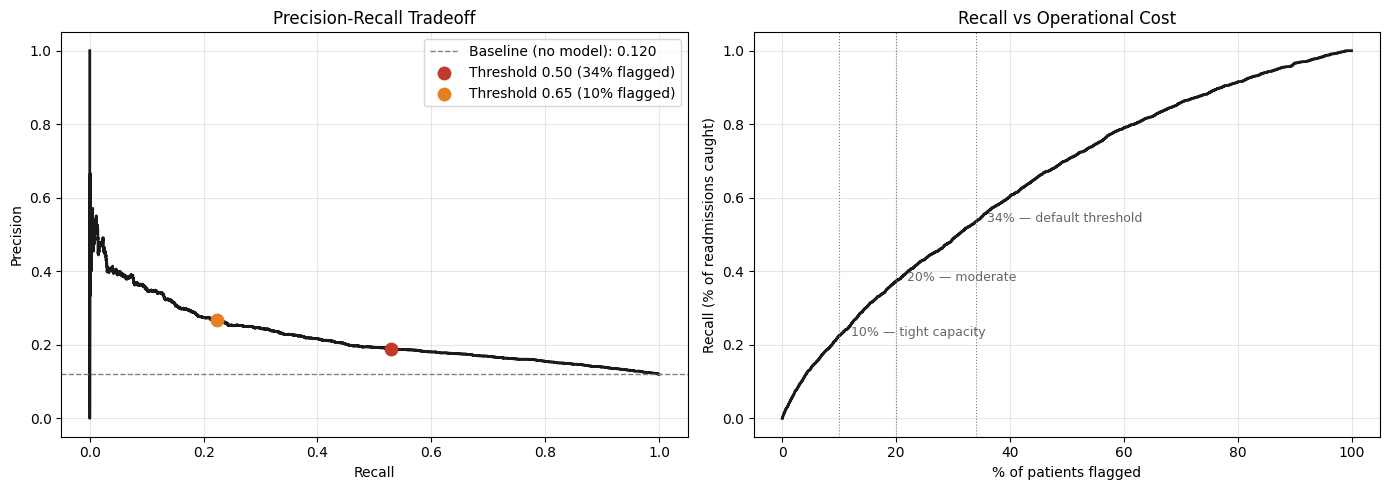

In [22]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

os.makedirs('figures', exist_ok=True)

# Compute PR curve points across all thresholds
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_test_proba)

# Compute flag rate at each threshold (for capacity reasoning)
# thresholds_pr is 1 shorter than precision/recall arrays — sklearn convention
flag_rates = []
for t in thresholds_pr:
    flag_rates.append((y_test_proba >= t).mean())
flag_rates = np.array(flag_rates)

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision-Recall curve
ax = axes[0]
ax.plot(recall_curve, precision_curve, color='#1a1a1a', linewidth=2)
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', linewidth=1, 
           label=f'Baseline (no model): {y_test.mean():.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Tradeoff')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

# Mark the two operating points we've examined
default_recall = recall_score(y_test, y_test_pred)
default_precision = precision_score(y_test, y_test_pred)
capacity_recall = recall_score(y_test, y_test_pred_capacity)
capacity_precision = precision_score(y_test, y_test_pred_capacity)

ax.scatter([default_recall], [default_precision], color='#c0392b', s=80, zorder=5,
           label=f'Threshold 0.50 (34% flagged)')
ax.scatter([capacity_recall], [capacity_precision], color='#e67e22', s=80, zorder=5,
           label=f'Threshold 0.65 (10% flagged)')
ax.legend(loc='upper right')

# Plot 2: Recall vs Flag Rate (the operational view)
ax = axes[1]
ax.plot(flag_rates * 100, recall_curve[:-1], color='#1a1a1a', linewidth=2)
ax.set_xlabel('% of patients flagged')
ax.set_ylabel('Recall (% of readmissions caught)')
ax.set_title('Recall vs Operational Cost')
ax.grid(alpha=0.3)

# Mark realistic operating points
for flag_pct, label in [(10, '10% — tight capacity'), 
                         (20, '20% — moderate'), 
                         (34, '34% — default threshold')]:
    idx = np.argmin(np.abs(flag_rates * 100 - flag_pct))
    ax.axvline(x=flag_pct, color='gray', linestyle=':', linewidth=0.8)
    ax.annotate(label, xy=(flag_pct, recall_curve[idx]), 
                xytext=(flag_pct + 2, recall_curve[idx]),
                fontsize=9, color='#666')

plt.tight_layout()
plt.savefig('figures/baseline_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Baseline PR Curve Analysis

The baseline LR's PR curve shows weak discrimination — no threshold produces 
an operationally meaningful tradeoff. At a 10% flag rate (capacity-matched), 
recall is only 22%. At a 20% flag rate, recall reaches ~38%. Both are below 
what would be needed for the model to drive real follow-up decisions.

The curve is consistently above the 12% baseline (random flagging would 
give 12% precision at any recall), so the model carries some signal — but 
not enough at any operational point. This finding motivates testing 
non-linear models (Random Forest, XGBoost) in the next iteration to 
determine whether the feature signal can be better extracted.

In [24]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded, columns=feature_names)

print(f"Feature matrix shape: {X_train_df.shape}")
print(f"Sample feature names:")
for name in feature_names[:5]:
    print(f" {name}")
print(f" ... and {len(feature_names) - 5} more")

Feature matrix shape: (78283, 217)
Sample feature names:
 num__time_in_hospital
 num__num_lab_procedures
 num__num_procedures
 num__num_medications
 num__number_outpatient
 ... and 212 more


In [25]:
# compute correlation matrix
corr_matrix = X_train_df.corr().abs()

# Get upper triangle only (correlations are symmetric, no need to look at both halves)
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated pairs (threshold = 0.8)
high_corr_threshold  = 0.8

high_corr_pairs = []
for col in upper_triangle.columns:
    for idx in upper_triangle.index:
        corr_val = upper_triangle.loc[idx, col]
        if pd.notna(corr_val) and corr_val >= high_corr_threshold:
            high_corr_pairs.append((idx, col, corr_val))

# sort by correlation strength, descending
high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

print(f"Found {len(high_corr_pairs)} pairs with |correlation| >= {high_corr_threshold}")
print()
print(f"{'Feature 1':<60} {'Feature 2':<60} {'Corr':>6}")
print("=" * 130)
for feat1, feat2, corr in high_corr_pairs[:30]:  # show top 30
    print(f"{feat1:<60} {feat2:<60} {corr:>6.3f}")

Found 12 pairs with |correlation| >= 0.8

Feature 1                                                    Feature 2                                                      Corr
nom__glyburide-metformin_No                                  nom__glyburide-metformin_Steady                               0.991
nom__rosiglitazone_No                                        nom__rosiglitazone_Steady                                     0.977
nom__nateglinide_No                                          nom__nateglinide_Steady                                       0.976
nom__acarbose_No                                             nom__acarbose_Steady                                          0.975
nom__pioglitazone_No                                         nom__pioglitazone_Steady                                      0.974
nom__chlorpropamide_No                                       nom__chlorpropamide_Steady                                    0.955
nom__metformin_No                                      

In [26]:
medications_to_check = [
    'glyburide-metformin', 'rosiglitazone', 'nateglinide', 'acarbose',
    'pioglitazone', 'chlorpropamide', 'metformin', 'repaglinide',
    'glimepiride', 'glipizide', 'glyburide', 'miglitol'
]

# Load the pre-encoding training data to see raw category distributions
df_train = pd.read_csv('../data/df_train.csv')

for med in medications_to_check:
    print(f"\n{med}:")
    print(df_train[med].value_counts(normalize=True))


glyburide-metformin:
glyburide-metformin
No        0.993000
Steady    0.006873
Down      0.000064
Up        0.000064
Name: proportion, dtype: float64

rosiglitazone:
rosiglitazone
No        0.936959
Steady    0.060383
Up        0.001801
Down      0.000856
Name: proportion, dtype: float64

nateglinide:
nateglinide
No        0.992936
Steady    0.006732
Up        0.000217
Down      0.000115
Name: proportion, dtype: float64

acarbose:
acarbose
No        0.996832
Steady    0.003015
Up        0.000115
Down      0.000038
Name: proportion, dtype: float64

pioglitazone:
pioglitazone
No        0.927353
Steady    0.069134
Up        0.002287
Down      0.001226
Name: proportion, dtype: float64

chlorpropamide:
chlorpropamide
No        0.999131
Steady    0.000792
Up        0.000064
Down      0.000013
Name: proportion, dtype: float64

metformin:
metformin
No        0.799969
Steady    0.183693
Up        0.010666
Down      0.005672
Name: proportion, dtype: float64

repaglinide:
repaglinide
No        0

In [27]:
# Reload the raw cleaned data
df_train = pd.read_csv('../data/df_train.csv')
df_test = pd.read_csv('../data/df_test.csv')

# Apply previous low-variance drops
low_variance_features = [
    'examide', 'citoglipton',
    'tolbutamide', 'acetohexamide', 'troglitazone',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'glipizide-metformin', 'metformin-pioglitazone', 'tolazamide'
]
df_train = df_train.drop(columns=low_variance_features)
df_test = df_test.drop(columns=low_variance_features)

# NEW: Drop the four medications with <1% total non-"No" rate
additional_low_variance = ['chlorpropamide', 'miglitol', 'acarbose', 'glyburide-metformin']
df_train = df_train.drop(columns=additional_low_variance)
df_test = df_test.drop(columns=additional_low_variance)

# NEW: Binarize the 8 medications with real but skewed variation
to_binarize = ['metformin', 'glipizide', 'glyburide', 'pioglitazone',
               'rosiglitazone', 'glimepiride', 'repaglinide', 'nateglinide']

for med in to_binarize:
    # 'No' becomes 0, anything else (Steady/Up/Down) becomes 1
    df_train[med] = (df_train[med] != 'No').astype(int)
    df_test[med] = (df_test[med] != 'No').astype(int)

print(f"Dropped 4 additional low-variance medications: {additional_low_variance }")
print(f"Binarized 8 medications to taken/not-taken: {to_binarize}")
print(f"\nVerify binarization (metformin distribution):")
print(df_train['metformin'].value_counts(normalize=True))
print(f"\ndf_train shape: {df_train.shape}")

Dropped 4 additional low-variance medications: ['chlorpropamide', 'miglitol', 'acarbose', 'glyburide-metformin']
Binarized 8 medications to taken/not-taken: ['metformin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'glimepiride', 'repaglinide', 'nateglinide']

Verify binarization (metformin distribution):
metformin
0    0.799969
1    0.200031
Name: proportion, dtype: float64

df_train shape: (78283, 36)


In [28]:
# Numeric features — pass through with scaling
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'weight_recorded'
]

# Binary categoricals (string-encoded "Yes"/"No" etc) — need 0/1 mapping
binary_cols = ['gender', 'change', 'diabetesMed']

# Already-binary numeric (we did this transformation manually) — pass through
already_binary = ['metformin', 'glipizide', 'glyburide', 'pioglitazone',
                   'rosiglitazone', 'glimepiride', 'repaglinide', 'nateglinide']

# Ordinal — preserve order
ordinal_cols = ['age']
age_order = [['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
              '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']]

# Multi-class nominal — one-hot encode
nominal_cols = [
    'race', 'max_glu_serum', 'A1Cresult',
    'medical_specialty', 'payer_code',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'diag_1', 'diag_2', 'diag_3',
    'insulin'  # the only remaining 4-value medication
]

# Verify accounting
X_train = df_train.drop(columns=['encounter_id', 'patient_nbr', 'target'])
all_grouped = numeric_cols + binary_cols + already_binary + ordinal_cols + nominal_cols
missing = set(X_train.columns) - set(all_grouped)
extra = set(all_grouped) - set(X_train.columns)
print(f"Total feature columns: {X_train.shape[1]}")
print(f"Accounted for: {len(all_grouped)}")
print(f"Missing: {missing}")
print(f"Extra: {extra}")

Total feature columns: 33
Accounted for: 33
Missing: set()
Extra: set()


In [29]:
print("Insulin distribution in training data:")
print(df_train['insulin'].value_counts(normalize=True))

Insulin distribution in training data:
insulin
No        0.467675
Steady    0.301304
Down      0.120384
Up        0.110637
Name: proportion, dtype: float64


In [32]:
def group_icd9(code):
    """Group ICD-9 codes into 9 clinical categories."""
    if pd.isna(code):
        return 'Other'
    code_str = str(code)
    if code_str.startswith('V') or code_str.startswith('E'):
        return 'Other'
    try:
        code_num = float(code_str)
    except ValueError:
        return 'Other'
    if 250 <= code_num < 251:
        return 'Diabetes'
    if 390 <= code_num < 460:
        return 'Circulatory'
    if 460 <= code_num < 520:
        return 'Respiratory'
    if 520 <= code_num < 580:
        return 'Digestive'
    if 580 <= code_num < 630:
        return 'Genitourinary'
    if 140 <= code_num < 240:
        return 'Neoplasms'
    if 800 <= code_num < 1000:
        return 'Injury'
    if 710 <= code_num < 740:
        return 'Musculoskeletal'
    return 'Other'

# === Step 1: Load fresh data ===
df_train = pd.read_csv('../data/df_train.csv')
df_test = pd.read_csv('../data/df_test.csv')

# === Step 2: Drop low-variance medications (original 10) ===
df_train = df_train.drop(columns=low_variance_features)
df_test = df_test.drop(columns=low_variance_features)

# === Step 3: Drop the additional 4 low-variance medications ===
df_train = df_train.drop(columns=additional_low_variance)
df_test = df_test.drop(columns=additional_low_variance)

# === Step 4: Binarize the 8 skewed-distribution medications ===
for med in to_binarize:
    df_train[med] = (df_train[med] != 'No').astype(int)
    df_test[med] = (df_test[med] != 'No').astype(int)

# === Step 5: Group ICD-9 codes into 9 clinical categories ===
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_train[col] = df_train[col].apply(group_icd9)
    df_test[col] = df_test[col].apply(group_icd9)

# Verify the grouping
print("After ICD-9 grouping:")
for col in ['diag_1', 'diag_2', 'diag_3']:
    print(f"  {col}: {df_train[col].nunique()} unique values")

# === Step 6: Separate features and target ===
X_train = df_train.drop(columns=['encounter_id', 'patient_nbr', 'target'])
y_train = df_train['target']
X_test = df_test.drop(columns=['encounter_id', 'patient_nbr', 'target'])
y_test = df_test['target']

# === Step 7: Build and fit the ColumnTransformer ===
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('bin', OrdinalEncoder(), binary_cols),
        ('ord', OrdinalEncoder(categories=age_order), ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), nominal_cols),
        ('passthrough_binary', 'passthrough', already_binary),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(f"\nX_train encoded shape: {X_train_encoded.shape}")
print(f"X_test encoded shape:  {X_test_encoded.shape}")
print(f"\nReduction from baseline: 217 → {X_train_encoded.shape[1]}")

After ICD-9 grouping:
  diag_1: 9 unique values
  diag_2: 9 unique values
  diag_3: 9 unique values

X_train encoded shape: (78283, 189)
X_test encoded shape:  (19539, 189)

Reduction from baseline: 217 → 189


/home/sharon/anaconda3/envs/datacareer/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [3, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [33]:
# Get the feature names from the new preprocessor
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded, columns=feature_names)

# Compute correlation matrix
corr_matrix = X_train_df.corr().abs()

# Upper triangle only
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find pairs above threshold
high_corr_threshold = 0.8
high_corr_pairs = []
for col in upper_triangle.columns:
    for idx in upper_triangle.index:
        corr_val = upper_triangle.loc[idx, col]
        if pd.notna(corr_val) and corr_val >= high_corr_threshold:
            high_corr_pairs.append((idx, col, corr_val))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

print(f"Pairs with |correlation| >= {high_corr_threshold}: {len(high_corr_pairs)}")
print()
if high_corr_pairs:
    print(f"{'Feature 1':<60} {'Feature 2':<60} {'Corr':>6}")
    print("=" * 130)
    for feat1, feat2, corr in high_corr_pairs[:20]:
        print(f"{feat1:<60} {feat2:<60} {corr:>6.3f}")
else:
    print("No high-correlation pairs found. Multicollinearity has been resolved.")

Pairs with |correlation| >= 0.8: 0

No high-correlation pairs found. Multicollinearity has been resolved.


## Multicollinearity Resolution

Initial check at 217 features identified 12 pairs with correlation ≥ 0.8 — 
all involving medication features where the No vs Steady distinction 
dominated. Two corrective actions:
1. Dropped 4 medications with <1% combined non-"No" rate (chlorpropamide, 
   miglitol, acarbose, glyburide-metformin)
2. Binarized 8 medications with real but heavily skewed distributions to 
   taken/not-taken (metformin, glipizide, glyburide, pioglitazone, 
   rosiglitazone, glimepiride, repaglinide, nateglinide)

Re-check at 189 features: zero pairs above 0.8 correlation threshold. 
Multicollinearity resolved.

In [34]:
# Save the fully-transformed (but pre-encoding) training data
df_train.to_csv('../data/df_train_v2.csv', index=False)
df_test.to_csv('../data/df_test_v2.csv', index=False)

print(f"Saved df_train_v2.csv: {df_train.shape}")
print(f"Saved df_test_v2.csv:  {df_test.shape}")

Saved df_train_v2.csv: (78283, 36)
Saved df_test_v2.csv:  (19539, 36)


In [35]:
check = pd.read_csv('../data/df_train_v2.csv')
print(f"diag_1 unique values: {check['diag_1'].nunique()}")  # should be 9
print(f"metformin dtype: {check['metformin'].dtype}")  # should be int

diag_1 unique values: 9
metformin dtype: int64
